In [1]:
from pathlib import Path
import sys

# Go from notebooks/ to project root
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\MedVision-AI


# Notebook 10: Explainable AI using Grad-CAM

## MedVision-AI


---

### Overview

Deep learning models have demonstrated remarkable performance in medical image analysis. However, these models are often criticized for functioning as "black boxes," providing highly accurate predictions without explaining the reasoning behind them.

In medical applications, explainability is essential because clinicians must understand the evidence supporting an automated diagnosis before incorporating AI predictions into clinical decision-making.

This notebook demonstrates the explainability component of the **MedVision-AI** project using **Gradient-weighted Class Activation Mapping (Grad-CAM)**. The notebook loads a trained EfficientNet-B0 model, generates class activation maps, visualizes the regions influencing the model's predictions, and creates structured prediction reports for chest X-ray images.

# Objectives

The objectives of this notebook are to:

- Load the trained EfficientNet-B0 classification model.
- Restore the best model checkpoint obtained during training.
- Verify the model architecture and selected Grad-CAM target layer.
- Predict the class of a chest X-ray image.
- Generate Grad-CAM activation heatmaps.
- Visualize model attention using overlay images.
- Produce structured prediction reports.
- Demonstrate explainable AI for medical image classification.

# Notebook Workflow

The explainability pipeline consists of the following stages:

1. Import required libraries.
2. Configure project paths and runtime settings.
3. Load the trained EfficientNet-B0 model.
4. Restore trained model weights.
5. Verify the Grad-CAM target layer.
6. Load and preprocess a test image.
7. Perform model prediction.
8. Generate the Grad-CAM heatmap.
9. Visualize model attention.
10. Generate a prediction report.
11. Save explainability outputs.

In [13]:
# ============================================================
# Standard Library Imports
# ============================================================

from pathlib import Path

# ============================================================
# Third-Party Imports
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

import torch
from PIL import Image

# ============================================================
# Project Imports
# ============================================================

from app.models.efficientnet import (
    build_efficientnet_b0,
)

from app.preprocessing.transforms import (
    test_transform,
)

from app.training.checkpoint import (
    load_checkpoint,
)

from app.explainability.gradcam import (
    GradCAM,
)

from app.explainability.visualization import (
    visualize_gradcam,
    save_visualization,
)

from app.explainability.report import (
    generate_report,
    format_report,
    save_report,
)

# Project Configuration

The following configuration specifies the locations of the trained model, dataset, output directory, and runtime device.

Centralizing configuration values improves notebook readability and simplifies future modifications.

In [14]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path.cwd().parent

OUTPUT_DIR = PROJECT_ROOT / "outputs"

VISUALIZATION_DIR = OUTPUT_DIR / "visualizations"

REPORT_DIR = OUTPUT_DIR / "reports"

VISUALIZATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [24]:
# ============================================================
# Locate Best Model Checkpoint
# ============================================================

checkpoint_candidates = [
    PROJECT_ROOT / "checkpoints" / "best_model.pth",
    PROJECT_ROOT / "outputs" / "checkpoints" / "best_model.pth",
    PROJECT_ROOT / "notebooks" / "checkpoints" / "best_model.pth",
]

CHECKPOINT_PATH = None

for path in checkpoint_candidates:
    if path.exists():
        CHECKPOINT_PATH = path
        break

if CHECKPOINT_PATH is None:
    raise FileNotFoundError(
        "Could not locate best_model.pth."
    )

print("=" * 60)
print("Checkpoint Found")
print("=" * 60)
print(CHECKPOINT_PATH)

Checkpoint Found
c:\MedVision-AI\checkpoints\best_model.pth


In [25]:
# ============================================================
# Device
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f"Using device: {DEVICE}")

Using device: cuda


# Build Model

Construct the EfficientNet-B0 architecture used during training.

The model architecture must exactly match the architecture used to generate the checkpoint before loading trained weights.

In [26]:
# ============================================================
# Build EfficientNet-B0
# ============================================================

model = build_efficientnet_b0(
    num_classes=2,
    pretrained=False,
    freeze_backbone=False,
)

model.to(DEVICE)

print(model.__class__.__name__)

EfficientNet


In [27]:
# ============================================================
# Load Trained Model
# ============================================================

checkpoint = load_checkpoint(
    CHECKPOINT_PATH,
    model,
)

model.to(DEVICE)

model.eval()

print("=" * 60)
print("Checkpoint Loaded Successfully")
print("=" * 60)

print(f"Epoch            : {checkpoint['epoch']}")
print(f"Validation Loss  : {checkpoint['val_loss']:.4f}")

Checkpoint Loaded Successfully
Epoch            : 5
Validation Loss  : 0.2416


In [32]:
# ============================================================
# Select Test Image Automatically
# ============================================================

DATASET_DIR = (
    PROJECT_ROOT
    / "dataset"
    / "chest_xray"
    / "test"
)

image_files = sorted(
    list(DATASET_DIR.rglob("*.jpeg")) +
    list(DATASET_DIR.rglob("*.jpg")) +
    list(DATASET_DIR.rglob("*.png"))
)

if not image_files:
    raise FileNotFoundError(
        "No test images were found."
    )

IMAGE_PATH = image_files[0]

print("=" * 60)
print("Selected Image")
print("=" * 60)
print(IMAGE_PATH)

Selected Image
c:\MedVision-AI\dataset\chest_xray\test\NORMAL\IM-0001-0001.jpeg


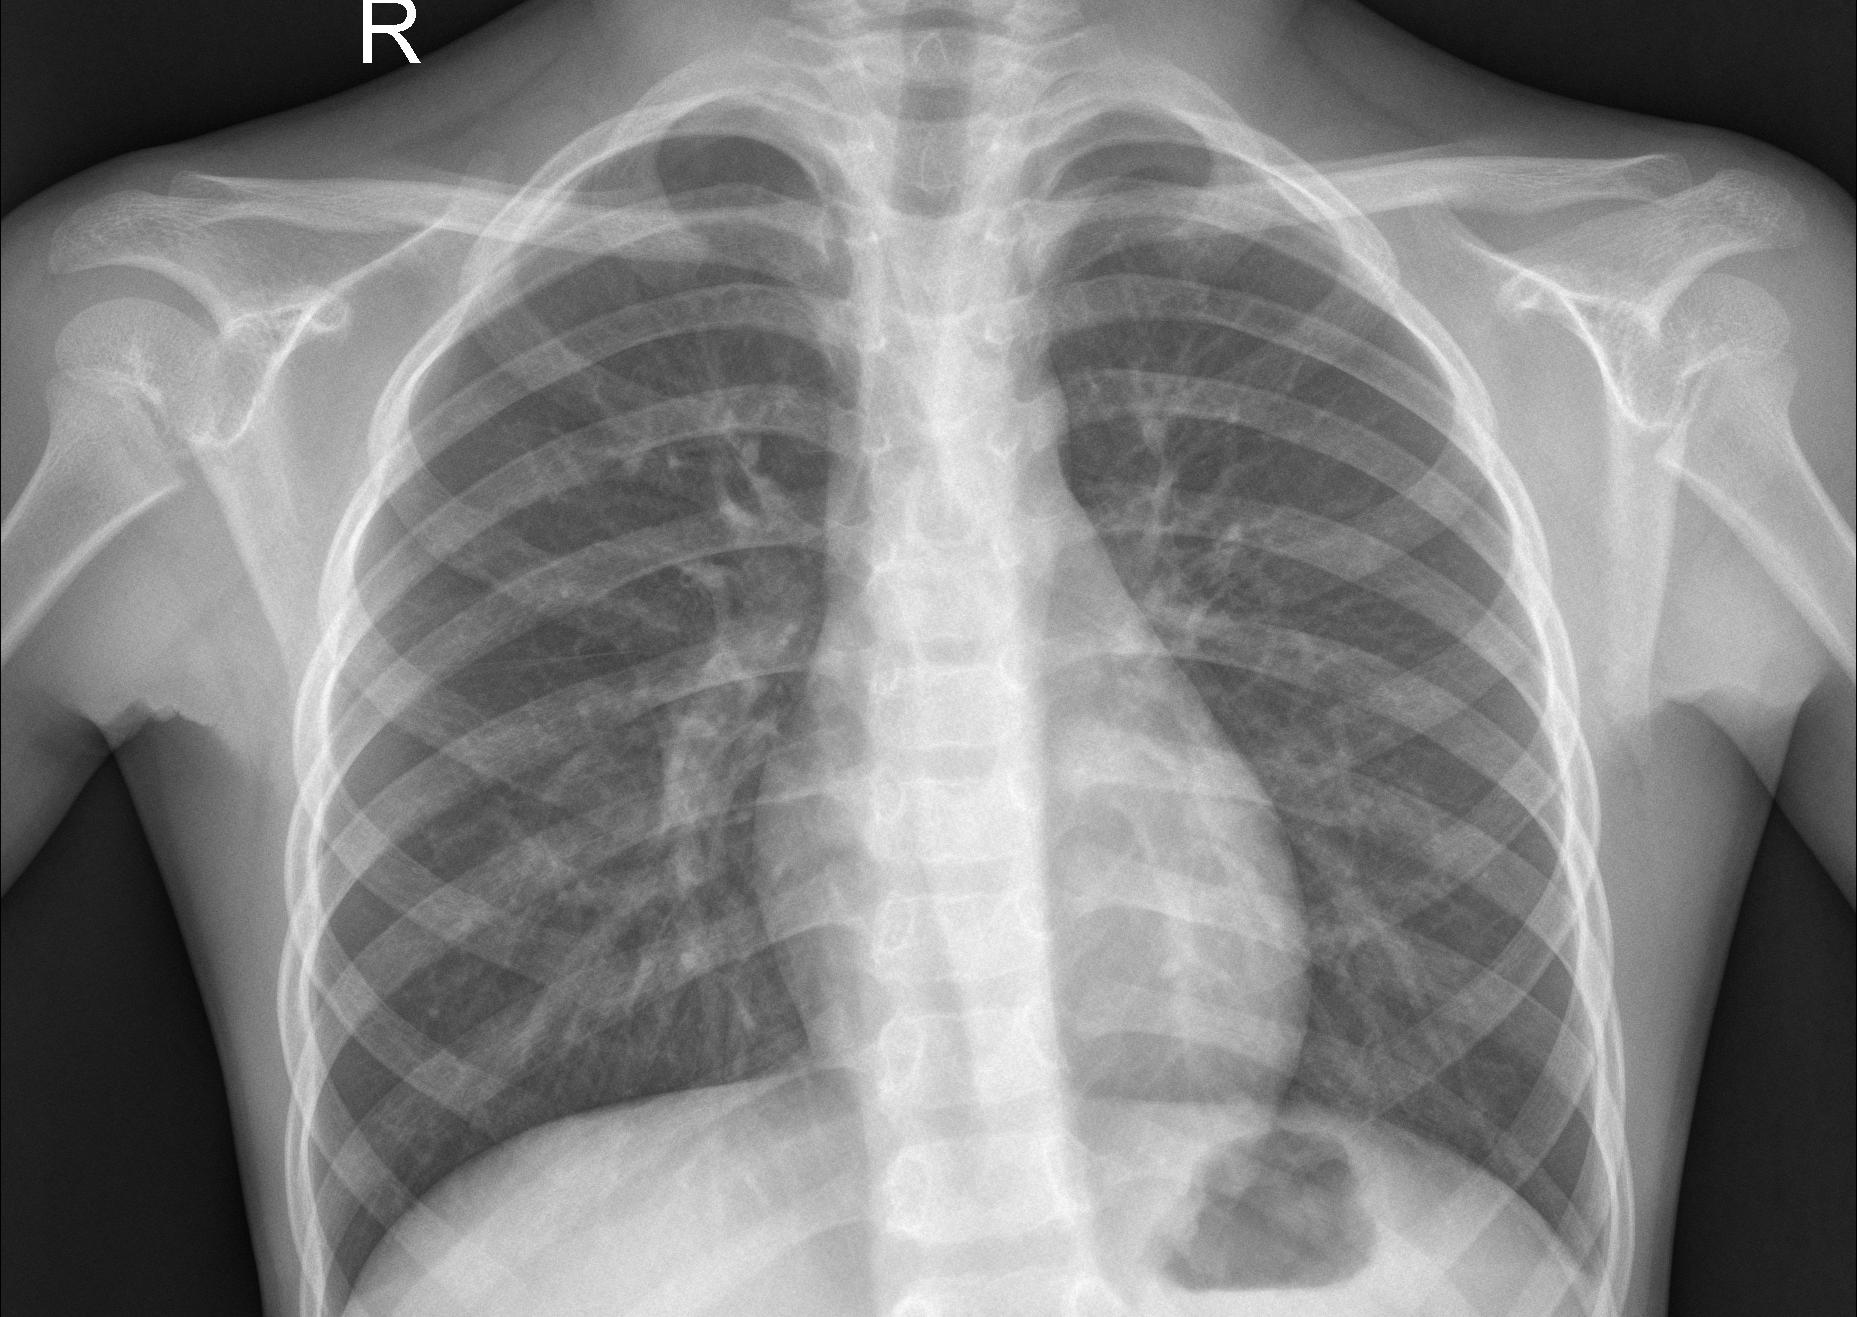

In [33]:
# ============================================================
# Load Image
# ============================================================

image = Image.open(
    IMAGE_PATH
).convert("RGB")

display(image)

In [34]:
# ============================================================
# Preprocess Image
# ============================================================

input_tensor = test_transform(
    image
).unsqueeze(0)

input_tensor = input_tensor.to(DEVICE)

print("Tensor Shape :", input_tensor.shape)

Tensor Shape : torch.Size([1, 3, 224, 224])


In [35]:
# ============================================================
# Prediction
# ============================================================

CLASS_NAMES = [
    "NORMAL",
    "PNEUMONIA",
]

model.eval()

with torch.no_grad():

    logits = model(input_tensor)

    probabilities = torch.softmax(
        logits,
        dim=1,
    )

    confidence, predicted_idx = torch.max(
        probabilities,
        dim=1,
    )

predicted_idx = predicted_idx.item()

confidence = confidence.item()

predicted_class = CLASS_NAMES[predicted_idx]

In [36]:
# ============================================================
# Prediction Results
# ============================================================

print("=" * 60)
print("Prediction")
print("=" * 60)

print(f"Predicted Class : {predicted_class}")

print(f"Confidence      : {confidence:.2%}")

Prediction
Predicted Class : NORMAL
Confidence      : 55.64%


In [37]:
# ============================================================
# Class Probabilities
# ============================================================

print("=" * 60)
print("Prediction Probabilities")
print("=" * 60)

for class_name, probability in zip(
    CLASS_NAMES,
    probabilities.squeeze(),
):
    print(
        f"{class_name:<12}: {probability.item():.2%}"
    )

Prediction Probabilities
NORMAL      : 55.64%
PNEUMONIA   : 44.36%


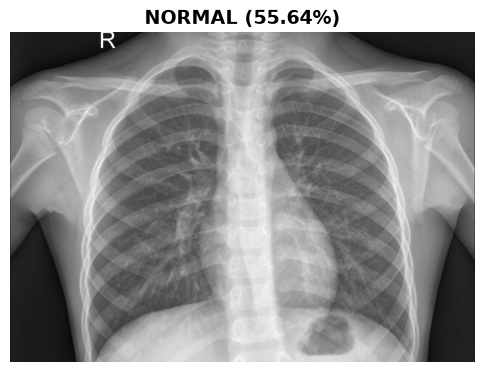

In [38]:
# ============================================================
# Display Original Image
# ============================================================

plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.axis("off")

plt.title(
    f"{predicted_class} ({confidence:.2%})",
    fontsize=14,
    fontweight="bold",
)

plt.show()

In [39]:
# ============================================================
# Initialize Grad-CAM
# ============================================================

target_layer = model.features[-1]

gradcam = GradCAM(
    model=model,
    target_layer=target_layer,
)

print("Grad-CAM initialized successfully.")

Grad-CAM initialized successfully.


In [40]:
# ============================================================
# Generate Grad-CAM Heatmap
# ============================================================

heatmap = gradcam.generate(
    image_tensor=input_tensor,
    target_class=predicted_idx,
)

print("Heatmap Shape :", heatmap.shape)

Heatmap Shape : (224, 224)


In [42]:
# ============================================================
# Convert Image to NumPy
# ============================================================

image_np = np.array(image)

print(image_np.shape)
print(image_np.dtype)

(1317, 1857, 3)
uint8


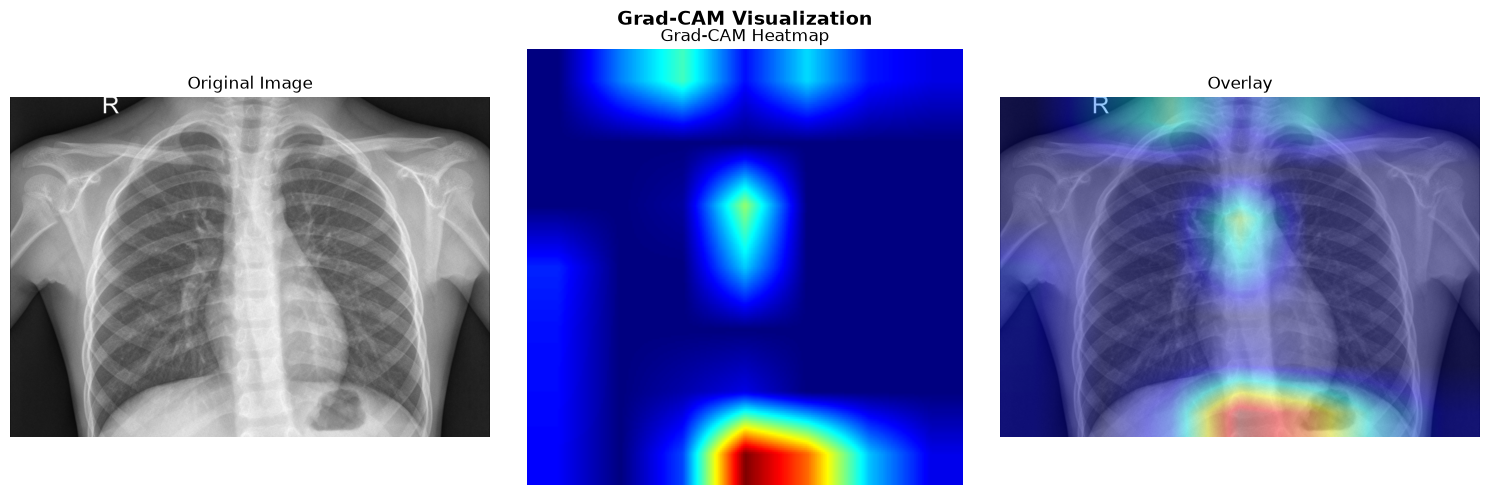

In [43]:
# ============================================================
# Visualize Grad-CAM
# ============================================================

figure = visualize_gradcam(
    image=image_np,
    heatmap=heatmap,
)

plt.show()

In [45]:
# ============================================================
# Save Visualization
# ============================================================

VISUALIZATION_PATH = (
    VISUALIZATION_DIR
    / f"{IMAGE_PATH.stem}_gradcam.png"
)

save_visualization(
    figure=figure,
    filepath=VISUALIZATION_PATH,
    dpi=300,
)

print("=" * 60)
print("Visualization Saved")
print("=" * 60)
print(VISUALIZATION_PATH)

Visualization Saved
c:\MedVision-AI\outputs\visualizations\IM-0001-0001_gradcam.png


In [46]:
# ============================================================
# Generate Prediction Report
# ============================================================

report = generate_report(
    image_name=IMAGE_PATH.name,
    predicted_class=predicted_class,
    confidence=confidence,
)

print(format_report(report))

MedVision-AI Prediction Report
Image           : IM-0001-0001.jpeg
Prediction      : NORMAL
Confidence      : 55.64%
Grad-CAM        : Generated
Timestamp       : 2026-07-20 20:53:21

Interpretation
------------------------------------------------------------
The model did not identify imaging patterns suggestive of pneumonia. The Grad-CAM visualization highlights the image regions considered during prediction. This output should be interpreted together with clinical findings and radiological expertise.


In [47]:
# ============================================================
# Save Prediction Report
# ============================================================

REPORT_PATH = (
    REPORT_DIR
    / f"{IMAGE_PATH.stem}_report.json"
)

save_report(
    report=report,
    filepath=REPORT_PATH,
)

print("=" * 60)
print("Report Saved")
print("=" * 60)
print(REPORT_PATH)

Report Saved
c:\MedVision-AI\outputs\reports\IM-0001-0001_report.json


In [48]:
# ============================================================
# Cleanup
# ============================================================

gradcam.remove_hooks()

print("Grad-CAM hooks removed.")

Grad-CAM hooks removed.


In [49]:
# ============================================================
# Notebook Completed
# ============================================================

print("=" * 60)
print("MedVision-AI Explainability Pipeline Completed Successfully")
print("=" * 60)

print(f"Input Image      : {IMAGE_PATH.name}")
print(f"Prediction       : {predicted_class}")
print(f"Confidence       : {confidence:.2%}")
print(f"Grad-CAM Image   : {VISUALIZATION_PATH}")
print(f"Prediction Report: {REPORT_PATH}")

MedVision-AI Explainability Pipeline Completed Successfully
Input Image      : IM-0001-0001.jpeg
Prediction       : NORMAL
Confidence       : 55.64%
Grad-CAM Image   : c:\MedVision-AI\outputs\visualizations\IM-0001-0001_gradcam.png
Prediction Report: c:\MedVision-AI\outputs\reports\IM-0001-0001_report.json
